
=== Motion Blur ===
Inverse    | PSNR=9.06 | SSIM=0.012 | Time=0.0516
Wiener     | PSNR=13.18 | SSIM=0.275 | Time=0.0583
Lucy       | PSNR=25.14 | SSIM=0.882 | Time=6.7439


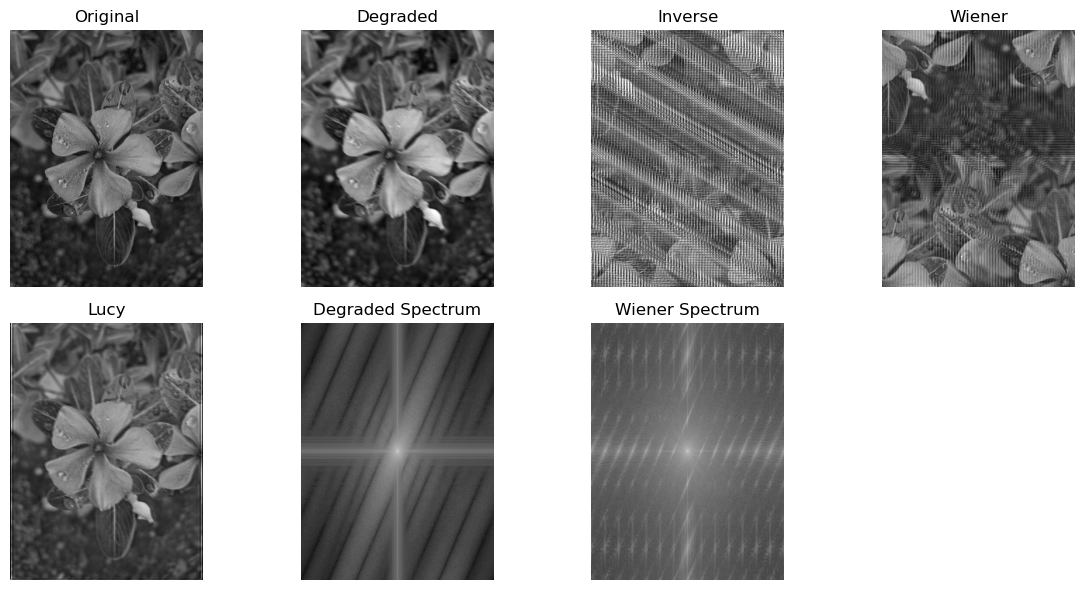


=== Gaussian + Blur ===
Inverse    | PSNR=3.89 | SSIM=0.020 | Time=0.0515
Wiener     | PSNR=13.76 | SSIM=0.309 | Time=0.0566
Lucy       | PSNR=19.28 | SSIM=0.151 | Time=7.3545


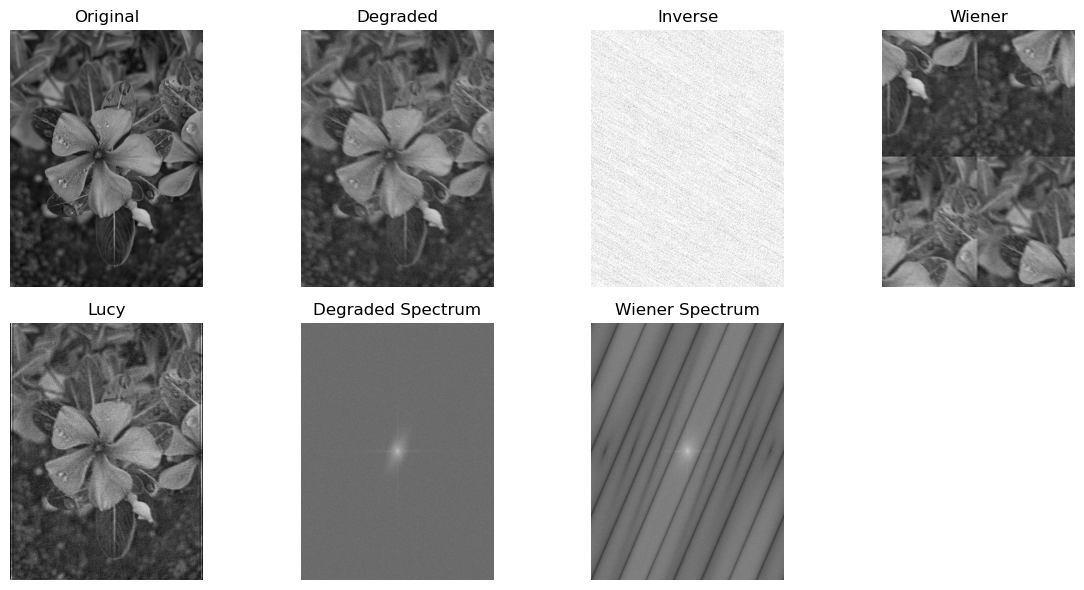


=== Salt&Pepper + Blur ===
Inverse    | PSNR=3.65 | SSIM=0.065 | Time=0.0520
Wiener     | PSNR=11.82 | SSIM=0.367 | Time=0.0621
Lucy       | PSNR=14.74 | SSIM=0.056 | Time=7.8286


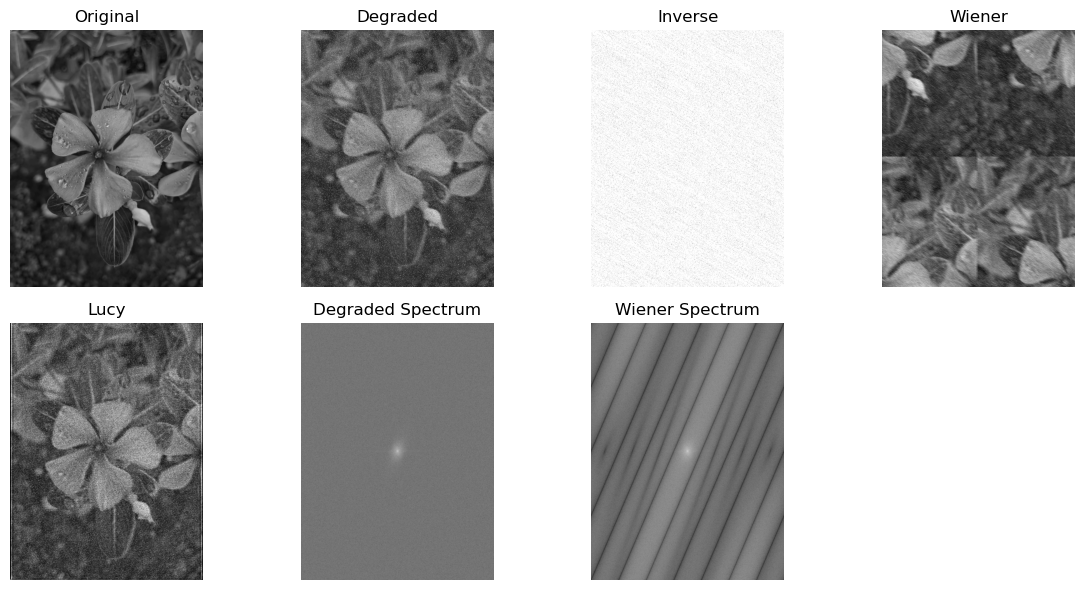

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from scipy.signal import convolve2d
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from skimage.metrics import structural_similarity as ssim

# =========================================================
# 1. LOAD IMAGE
# =========================================================
def load_image():
    img = cv2.imread('bunga.jpeg', cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.zeros((256,256), dtype=np.uint8)
        cv2.rectangle(img,(30,30),(100,100),200,-1)
        cv2.circle(img,(180,80),40,150,-1)
        cv2.putText(img,'TEST',(80,180),cv2.FONT_HERSHEY_SIMPLEX,1,180,2)
    return img.astype(np.float32)


# =========================================================
# 2. PSF ESTIMATION
# =========================================================
def estimate_motion_psf(length=15, angle=30):
    psf = np.zeros((length, length))
    center = length // 2
    angle = np.deg2rad(angle)

    for i in range(length):
        x = int(center + (i - center) * np.cos(angle))
        y = int(center + (i - center) * np.sin(angle))
        if 0 <= x < length and 0 <= y < length:
            psf[y, x] = 1

    psf /= np.sum(psf)
    return psf


# =========================================================
# 3. DEGRADATION
# =========================================================
def motion_blur(img, psf):
    return cv2.filter2D(img, -1, psf)

def gaussian_noise(img, sigma=20):
    noise = np.random.normal(0, sigma, img.shape)
    return np.clip(img + noise, 0, 255)

def sp_noise(img, prob=0.05):
    noisy = img.copy()
    num = int(prob * img.size)

    coords = [np.random.randint(0, i, num) for i in img.shape]
    noisy[coords[0], coords[1]] = 255
    coords = [np.random.randint(0, i, num) for i in img.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy


# =========================================================
# 4. FFT HELPER
# =========================================================
def psf2otf(psf, shape):
    padded = np.zeros(shape)
    padded[:psf.shape[0], :psf.shape[1]] = psf
    padded = ifftshift(padded)
    return fft2(padded)


# =========================================================
# 5. RESTORATION METHODS
# =========================================================
def inverse_filter(img, psf):
    G = fft2(img)
    H = psf2otf(psf, img.shape)

    H[np.abs(H) < 1e-3] = 1e-3  # stabilisasi

    F_hat = G / H
    result = np.abs(ifft2(F_hat))

    result = np.nan_to_num(result, nan=0.0, posinf=255.0, neginf=0.0)
    return np.clip(result, 0, 255)


def estimate_K(noisy, clean):
    noise = noisy - clean
    var_noise = np.var(noise)
    var_signal = np.var(clean)

    K = var_noise / (var_signal + 1e-6)
    return max(K, 1e-4)  # stabilisasi


def wiener_filter(img, psf, K):
    G = fft2(img)
    H = psf2otf(psf, img.shape)

    H_conj = np.conj(H)

    denom = np.abs(H)**2 + K
    denom = np.maximum(denom, 1e-6)

    F_hat = (H_conj / denom) * G
    result = np.abs(ifft2(F_hat))

    result = np.nan_to_num(result, nan=0.0, posinf=255.0, neginf=0.0)
    return np.clip(result, 0, 255)


def lucy_richardson(img, psf, iterations=10):
    img = img / 255.0
    estimate = np.full(img.shape, 0.5)

    psf_mirror = psf[::-1, ::-1]

    for _ in range(iterations):
        conv = convolve2d(estimate, psf, mode='same')
        relative_blur = img / (conv + 1e-6)
        estimate *= convolve2d(relative_blur, psf_mirror, mode='same')

    result = estimate * 255
    result = np.nan_to_num(result)
    return np.clip(result, 0, 255)


# =========================================================
# 6. METRICS
# =========================================================
def compute_metrics(original, restored):
    restored = np.nan_to_num(restored)
    restored = np.clip(restored, 0, 255)

    mse = np.mean((original - restored)**2)
    psnr = 10 * np.log10(255**2 / (mse + 1e-10))
    s = ssim(original.astype(np.uint8), restored.astype(np.uint8))

    return mse, psnr, s


# =========================================================
# 7. FREQUENCY VISUALIZATION
# =========================================================
def show_spectrum(img, title):
    F = fftshift(fft2(img))
    magnitude = np.log(1 + np.abs(F))
    plt.imshow(magnitude, cmap='gray')
    plt.title(title)
    plt.axis('off')


# =========================================================
# 8. MAIN PIPELINE
# =========================================================
def run_pipeline():
    original = load_image()
    psf = estimate_motion_psf(15, 30)

    # Degradations
    blur = motion_blur(original, psf)
    gauss_blur = gaussian_noise(blur, 20)
    sp_blur = sp_noise(blur, 0.05)

    datasets = {
        "Motion Blur": blur,
        "Gaussian + Blur": gauss_blur,
        "Salt&Pepper + Blur": sp_blur
    }

    results = []

    for name, img in datasets.items():
        print(f"\n=== {name} ===")

        K = estimate_K(img, blur)

        # Inverse
        t0 = time.time()
        inv = inverse_filter(img, psf)
        t_inv = time.time() - t0

        # Wiener
        t0 = time.time()
        wie = wiener_filter(img, psf, K)
        t_wie = time.time() - t0

        # Lucy
        t0 = time.time()
        lucy = lucy_richardson(img, psf)
        t_lucy = time.time() - t0

        for method, out, t in [
            ("Inverse", inv, t_inv),
            ("Wiener", wie, t_wie),
            ("Lucy", lucy, t_lucy)
        ]:
            mse, psnr, s = compute_metrics(original, out)
            results.append([name, method, mse, psnr, s, t])

            print(f"{method:10s} | PSNR={psnr:.2f} | SSIM={s:.3f} | Time={t:.4f}")

        # Visualization
        plt.figure(figsize=(12,6))

        plt.subplot(2,4,1); plt.imshow(original, cmap='gray'); plt.title("Original"); plt.axis('off')
        plt.subplot(2,4,2); plt.imshow(img, cmap='gray'); plt.title("Degraded"); plt.axis('off')
        plt.subplot(2,4,3); plt.imshow(inv, cmap='gray'); plt.title("Inverse"); plt.axis('off')
        plt.subplot(2,4,4); plt.imshow(wie, cmap='gray'); plt.title("Wiener"); plt.axis('off')

        plt.subplot(2,4,5); plt.imshow(lucy, cmap='gray'); plt.title("Lucy"); plt.axis('off')
        plt.subplot(2,4,6); show_spectrum(img, "Degraded Spectrum")
        plt.subplot(2,4,7); show_spectrum(wie, "Wiener Spectrum")

        plt.tight_layout()
        plt.show()

    return results


# =========================================================
# RUN
# =========================================================
results = run_pipeline()